In [ ]:
# Bước 1: Cài đặt các thư viện cần thiết
!pip install yfinance python-dateutil

import yfinance as yf
import os
from datetime import date
from dateutil.relativedelta import relativedelta
from google.colab import drive

# Bước 2: Kết nối với Google Drive
# Lệnh này sẽ yêu cầu bạn xác thực tài khoản Google
print("Đang kết nối với Google Drive...")
drive.mount('/content/drive')
print("Kết nối Google Drive thành công!")

# Bước 3: Thiết lập các thông số
# --- BẠN PHẢI THAY ĐỔI DANH SÁCH NÀY ---
# Thay thế danh sách này bằng 60 mã cổ phiếu của bạn
# Ví dụ: ['AAPL', 'MSFT', 'GOOG', 'FPT.VN', 'HPG.VN', ...]
# Mã cổ phiếu quốc tế (Mỹ): 'AAPL', 'TSLA'
# Mã cổ phiếu Việt Nam (Sàn HOSE/HNX): 'FPT.VN', 'HPG.VN', 'ACB.VN'
ticker_list = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "GOOG", "TSLA", "COST", "PEP",
    "AVGO", "NFLX", "ADBE", "CSCO", "AMD", "INTC", "TXN", "QCOM", "AMAT", "INTU",
    "HON", "AMGN", "PYPL", "BKNG", "REGN", "ADI", "MU", "PANW", "MAR", "LRCX",
    "VRTX", "ADSK", "KLAC", "FTNT", "SNPS", "CDNS", "CSX", "PDD", "AEP", "ORLY",
    "GILD", "MELI", "CTAS", "MNST", "KDP", "NXPI", "ROST", "EXC", "PAYX", "ODFL",
    "WDAY", "PCAR", "MRVL", "IDXX", "CCEP", "TEAM", "CPRT", "CHTR", "XEL", "FAST",
    "DDOG", "CRWD", "ABNB", "ZS", "DOCU", "SIRI", "BIDU", "JD", "MRNA", "LULU"
]
# Tính toán khoảng thời gian 15 năm
end_date = date(2025, 10, 10)
start_date = end_date - relativedelta(years=15)

# Định nghĩa đường dẫn lưu file trên Google Drive
# File sẽ được lưu vào thư mục 'StockData_15Years' trong MyDrive của bạn
save_path = "/content/drive/MyDrive/StockData_15Years"

# Tạo thư mục nếu nó chưa tồn tại
os.makedirs(save_path, exist_ok=True)

print(f"Sẽ tải dữ liệu từ {start_date} đến {end_date}")
print(f"Dữ liệu sẽ được lưu tại: {save_path}")
print("-" * 30)

# Bước 4: Vòng lặp tải dữ liệu và lưu file
failed_tickers = []

for ticker in ticker_list:
    print(f"Đang xử lý mã: {ticker}...")
    try:
        # Tải dữ liệu từ Yahoo Finance
        data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

        # Kiểm tra xem có dữ liệu trả về không
        if data.empty:
            print(f"!!! Lỗi: Không tìm thấy dữ liệu cho mã {ticker} trong 15 năm qua.")
            failed_tickers.append(f"{ticker} (Không có dữ liệu)")
        else:
            # Dữ liệu tải về đã bao gồm 'Adj Close' (Adjusted Price)
            # Tạo tên file
            file_name = f"{ticker}.csv"
            full_file_path = os.path.join(save_path, file_name)

            # Lưu file vào Google Drive
            data.to_csv(full_file_path)
            print(f"==> Đã lưu thành công: {file_name}")

    except Exception as e:
        print(f"!!! Lỗi nghiêm trọng khi tải {ticker}: {e}")
        failed_tickers.append(f"{ticker} (Lỗi: {e})")

    print("-" * 30)

# Bước 5: Hoàn tất và thông báo
print("TẤT CẢ ĐÃ HOÀN TẤT!")
if failed_tickers:
    print("\nCác mã sau đã thất bại hoặc không có dữ liệu:")
    for ft in failed_tickers:
        print(f"- {ft}")
else:
    print("Tất cả 60 mã đã được tải về thành công!")

Đang kết nối với Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kết nối Google Drive thành công!
Sẽ tải dữ liệu từ 2010-10-10 đến 2025-10-10
Dữ liệu sẽ được lưu tại: /content/drive/MyDrive/StockData_15Years
------------------------------
Đang xử lý mã: AAPL...


[*********************100%***********************]  1 of 1 completed


==> Đã lưu thành công: AAPL.csv
------------------------------
Đang xử lý mã: MSFT...


[*********************100%***********************]  1 of 1 completed


==> Đã lưu thành công: MSFT.csv
------------------------------
Đang xử lý mã: NVDA...


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

==> Đã lưu thành công: JD.csv
------------------------------
Đang xử lý mã: MRNA...


==> Đã lưu thành công: MRNA.csv
------------------------------
Đang xử lý mã: LULU...


[*********************100%***********************]  1 of 1 completed

==> Đã lưu thành công: LULU.csv
------------------------------
TẤT CẢ ĐÃ HOÀN TẤT!
Tất cả 60 mã đã được tải về thành công!


In [ ]:
import pandas as pd
import os
import warnings

# Tắt các cảnh báo UserWarning không cần thiết
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. DANH SÁCH ĐẦY ĐỦ CÁC MÃ CẦN LÀM SẠCH ---
# Đây là toàn bộ danh sách 70 mã bạn đã tải về
ticker_list = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "GOOG", "TSLA", "COST", "PEP",
    "AVGO", "NFLX", "ADBE", "CSCO", "AMD", "INTC", "TXN", "QCOM", "AMAT", "INTU",
    "HON", "AMGN", "PYPL", "BKNG", "REGN", "ADI", "MU", "PANW", "MAR", "LRCX",
    "VRTX", "ADSK", "KLAC", "FTNT", "SNPS", "CDNS", "CSX", "PDD", "AEP", "ORLY",
    "GILD", "MELI", "CTAS", "MNST", "KDP", "NXPI", "ROST", "EXC", "PAYX", "ODFL",
    "WDAY", "PCAR", "MRVL", "IDXX", "CCEP", "TEAM", "CPRT", "CHTR", "XEL", "FAST",
    "DDOG", "CRWD", "ABNB", "ZS", "DOCU", "SIRI", "BIDU", "JD", "MRNA", "LULU"
]

# --- 2. ĐỊNH NGHĨA ĐƯỜNG DẪN ---
# Phải khớp với thư mục bạn đã lưu file
save_path = "/content/drive/MyDrive/StockData_15Years"

print(f"BẮT ĐẦU LÀM SẠCH VÀ GHI ĐÈ {len(ticker_list)} FILE CSV...")
print(f"Thư mục: {save_path}")
print("=" * 40)

success_count = 0
failed_tickers = []

# --- 3. VÒNG LẶP ĐỌC, LÀM SẠCH VÀ GHI ĐÈ ---
for ticker in ticker_list:

    file_name = f"{ticker}.csv"
    full_file_path = os.path.join(save_path, file_name)

    print(f"Đang xử lý file: {file_name}...")

    try:
        # BƯỚC 1: ĐỌC FILE LỘN XỘN VÀ LÀM SẠCH
        # - header=0: Chỉ lấy dòng 1 (Price, Adj Close...) làm tiêu đề
        # - index_col=0: Lấy cột 0 (Date) làm chỉ mục
        # - parse_dates=True: Chuyển cột chỉ mục thành dạng ngày tháng
        # - skiprows=[1, 2]: BỎ QUA dòng 2 (Ticker, MRNA...) và dòng 3 (Date rác)

        df_clean = pd.read_csv(
            full_file_path,
            header=0,
            index_col=0,
            parse_dates=True,
            skiprows=[1, 2]
        )

        # BƯỚC 2: GHI ĐÈ FILE CŨ BẰNG PHIÊN BẢN SẠCH
        # Ghi lại DataFrame (df_clean) vào đúng file đó
        # index=True để đảm bảo cột 'Date' (đang là index) được ghi lại

        df_clean.to_csv(full_file_path, index=True)

        print(f"==> Thành công: Đã làm sạch và ghi đè {file_name}")
        success_count += 1

    except FileNotFoundError:
        print(f"!!! LỖI: Không tìm thấy file {file_name}. Bỏ qua...")
        failed_tickers.append(f"{ticker} (Không tìm thấy)")
    except Exception as e:
        print(f"!!! LỖI: {e} với mã {ticker}. Bỏ qua...")
        failed_tickers.append(f"{ticker} (Lỗi: {e})")

    print("-" * 40)

# --- 4. TỔNG KẾT ---
print("TẤT CẢ ĐÃ HOÀN TẤT!")
print(f"Đã làm sạch và ghi lại thành công {success_count} / {len(ticker_list)} file.")

if failed_tickers:
    print("\nCác file sau đã thất bại (hãy kiểm tra lại):")
    for ft in failed_tickers:
        print(f"- {ft}")

BẮT ĐẦU LÀM SẠCH VÀ GHI ĐÈ 70 FILE CSV...
Thư mục: /content/drive/MyDrive/StockData_15Years
Đang xử lý file: AAPL.csv...
==> Thành công: Đã làm sạch và ghi đè AAPL.csv
----------------------------------------
Đang xử lý file: MSFT.csv...
==> Thành công: Đã làm sạch và ghi đè MSFT.csv
----------------------------------------
Đang xử lý file: NVDA.csv...
==> Thành công: Đã làm sạch và ghi đè NVDA.csv
----------------------------------------
Đang xử lý file: AMZN.csv...
==> Thành công: Đã làm sạch và ghi đè AMZN.csv
----------------------------------------
Đang xử lý file: META.csv...
==> Thành công: Đã làm sạch và ghi đè META.csv
----------------------------------------
Đang xử lý file: GOOGL.csv...
==> Thành công: Đã làm sạch và ghi đè GOOGL.csv
----------------------------------------
Đang xử lý file: GOOG.csv...
==> Thành công: Đã làm sạch và ghi đè GOOG.csv
----------------------------------------
Đang xử lý file: TSLA.csv...
==> Thành công: Đã làm sạch và ghi đè TSLA.csv
-----------

In [ ]:
import pandas as pd
import os
import warnings

# Tắt các cảnh báo không cần thiết
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. DANH SÁCH ĐẦY ĐỦ CÁC MÃ ---
ticker_list = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "GOOG", "TSLA", "COST", "PEP",
    "AVGO", "NFLX", "ADBE", "CSCO", "AMD", "INTC", "TXN", "QCOM", "AMAT", "INTU",
    "HON", "AMGN", "PYPL", "BKNG", "REGN", "ADI", "MU", "PANW", "MAR", "LRCX",
    "VRTX", "ADSK", "KLAC", "FTNT", "SNPS", "CDNS", "CSX", "PDD", "AEP", "ORLY",
    "GILD", "MELI", "CTAS", "MNST", "KDP", "NXPI", "ROST", "EXC", "PAYX", "ODFL",
    "WDAY", "PCAR", "MRVL", "IDXX", "CCEP", "TEAM", "CPRT", "CHTR", "XEL", "FAST",
    "DDOG", "CRWD", "ABNB", "ZS", "DOCU", "SIRI", "BIDU", "JD", "MRNA", "LULU"
]

# --- 2. ĐỊNH NGHĨA ĐƯỜNG DẪN ---
save_path = "/content/drive/MyDrive/StockData_15Years"

print(f"BẮT ĐẦU SỬA TÊN CỘT INDEX (Price -> Date) cho {len(ticker_list)} file...")
print("=" * 40)

success_count = 0
failed_tickers = []

# --- 3. VÒNG LẶP ĐỌC, SỬA TÊN VÀ GHI ĐÈ ---
for ticker in ticker_list:

    file_name = f"{ticker}.csv"
    full_file_path = os.path.join(save_path, file_name)

    try:
        # BƯỚC 1: ĐỌC FILE (với cột index tên là 'Price')
        df = pd.read_csv(
            full_file_path,
            index_col='Price',    # <--- Đọc file với tên cột index cũ
            parse_dates=True
        )

        # BƯỚC 2: SỬA TÊN CỘT INDEX
        df.index.name = 'Date'  # <--- Đặt lại tên mới là 'Date'

        # BƯỚC 3: GHI ĐÈ FILE
        df.to_csv(full_file_path, index=True)

        success_count += 1

    except FileNotFoundError:
        failed_tickers.append(f"{ticker} (Không tìm thấy)")
    except ValueError:
        # Bắt lỗi nếu file đã được sửa rồi (index_col='Price' không còn tồn tại)
        # Hoặc nếu file vẫn còn lộn xộn
        print(f"--- Cảnh báo: File {file_name} có thể đã được sửa hoặc có cấu trúc lạ. Bỏ qua...")
        failed_tickers.append(f"{ticker} (Cấu trúc lạ)")
    except Exception as e:
        failed_tickers.append(f"{ticker} (Lỗi: {e})")

print("-" * 40)
print("HOÀN TẤT SỬA LỖI!")
print(f"Đã xử lý {success_count} file.")
if failed_tickers:
    print("\nCác file sau không thể sửa (có thể bỏ qua nếu ít):", failed_tickers)

BẮT ĐẦU SỬA TÊN CỘT INDEX (Price -> Date) cho 70 file...
----------------------------------------
HOÀN TẤT SỬA LỖI!
Đã xử lý 70 file.


Bắt đầu vẽ 20 biểu đồ từ các file đã làm sạch...
----------------------------------------
----------------------------------------
TẤT CẢ ĐÃ HOÀN TẤT!
Đã lưu thành công ảnh tổng hợp 20 biểu đồ tại:
/content/drive/MyDrive/StockData_15Years/visualization_20_tickers_CLEAN.png


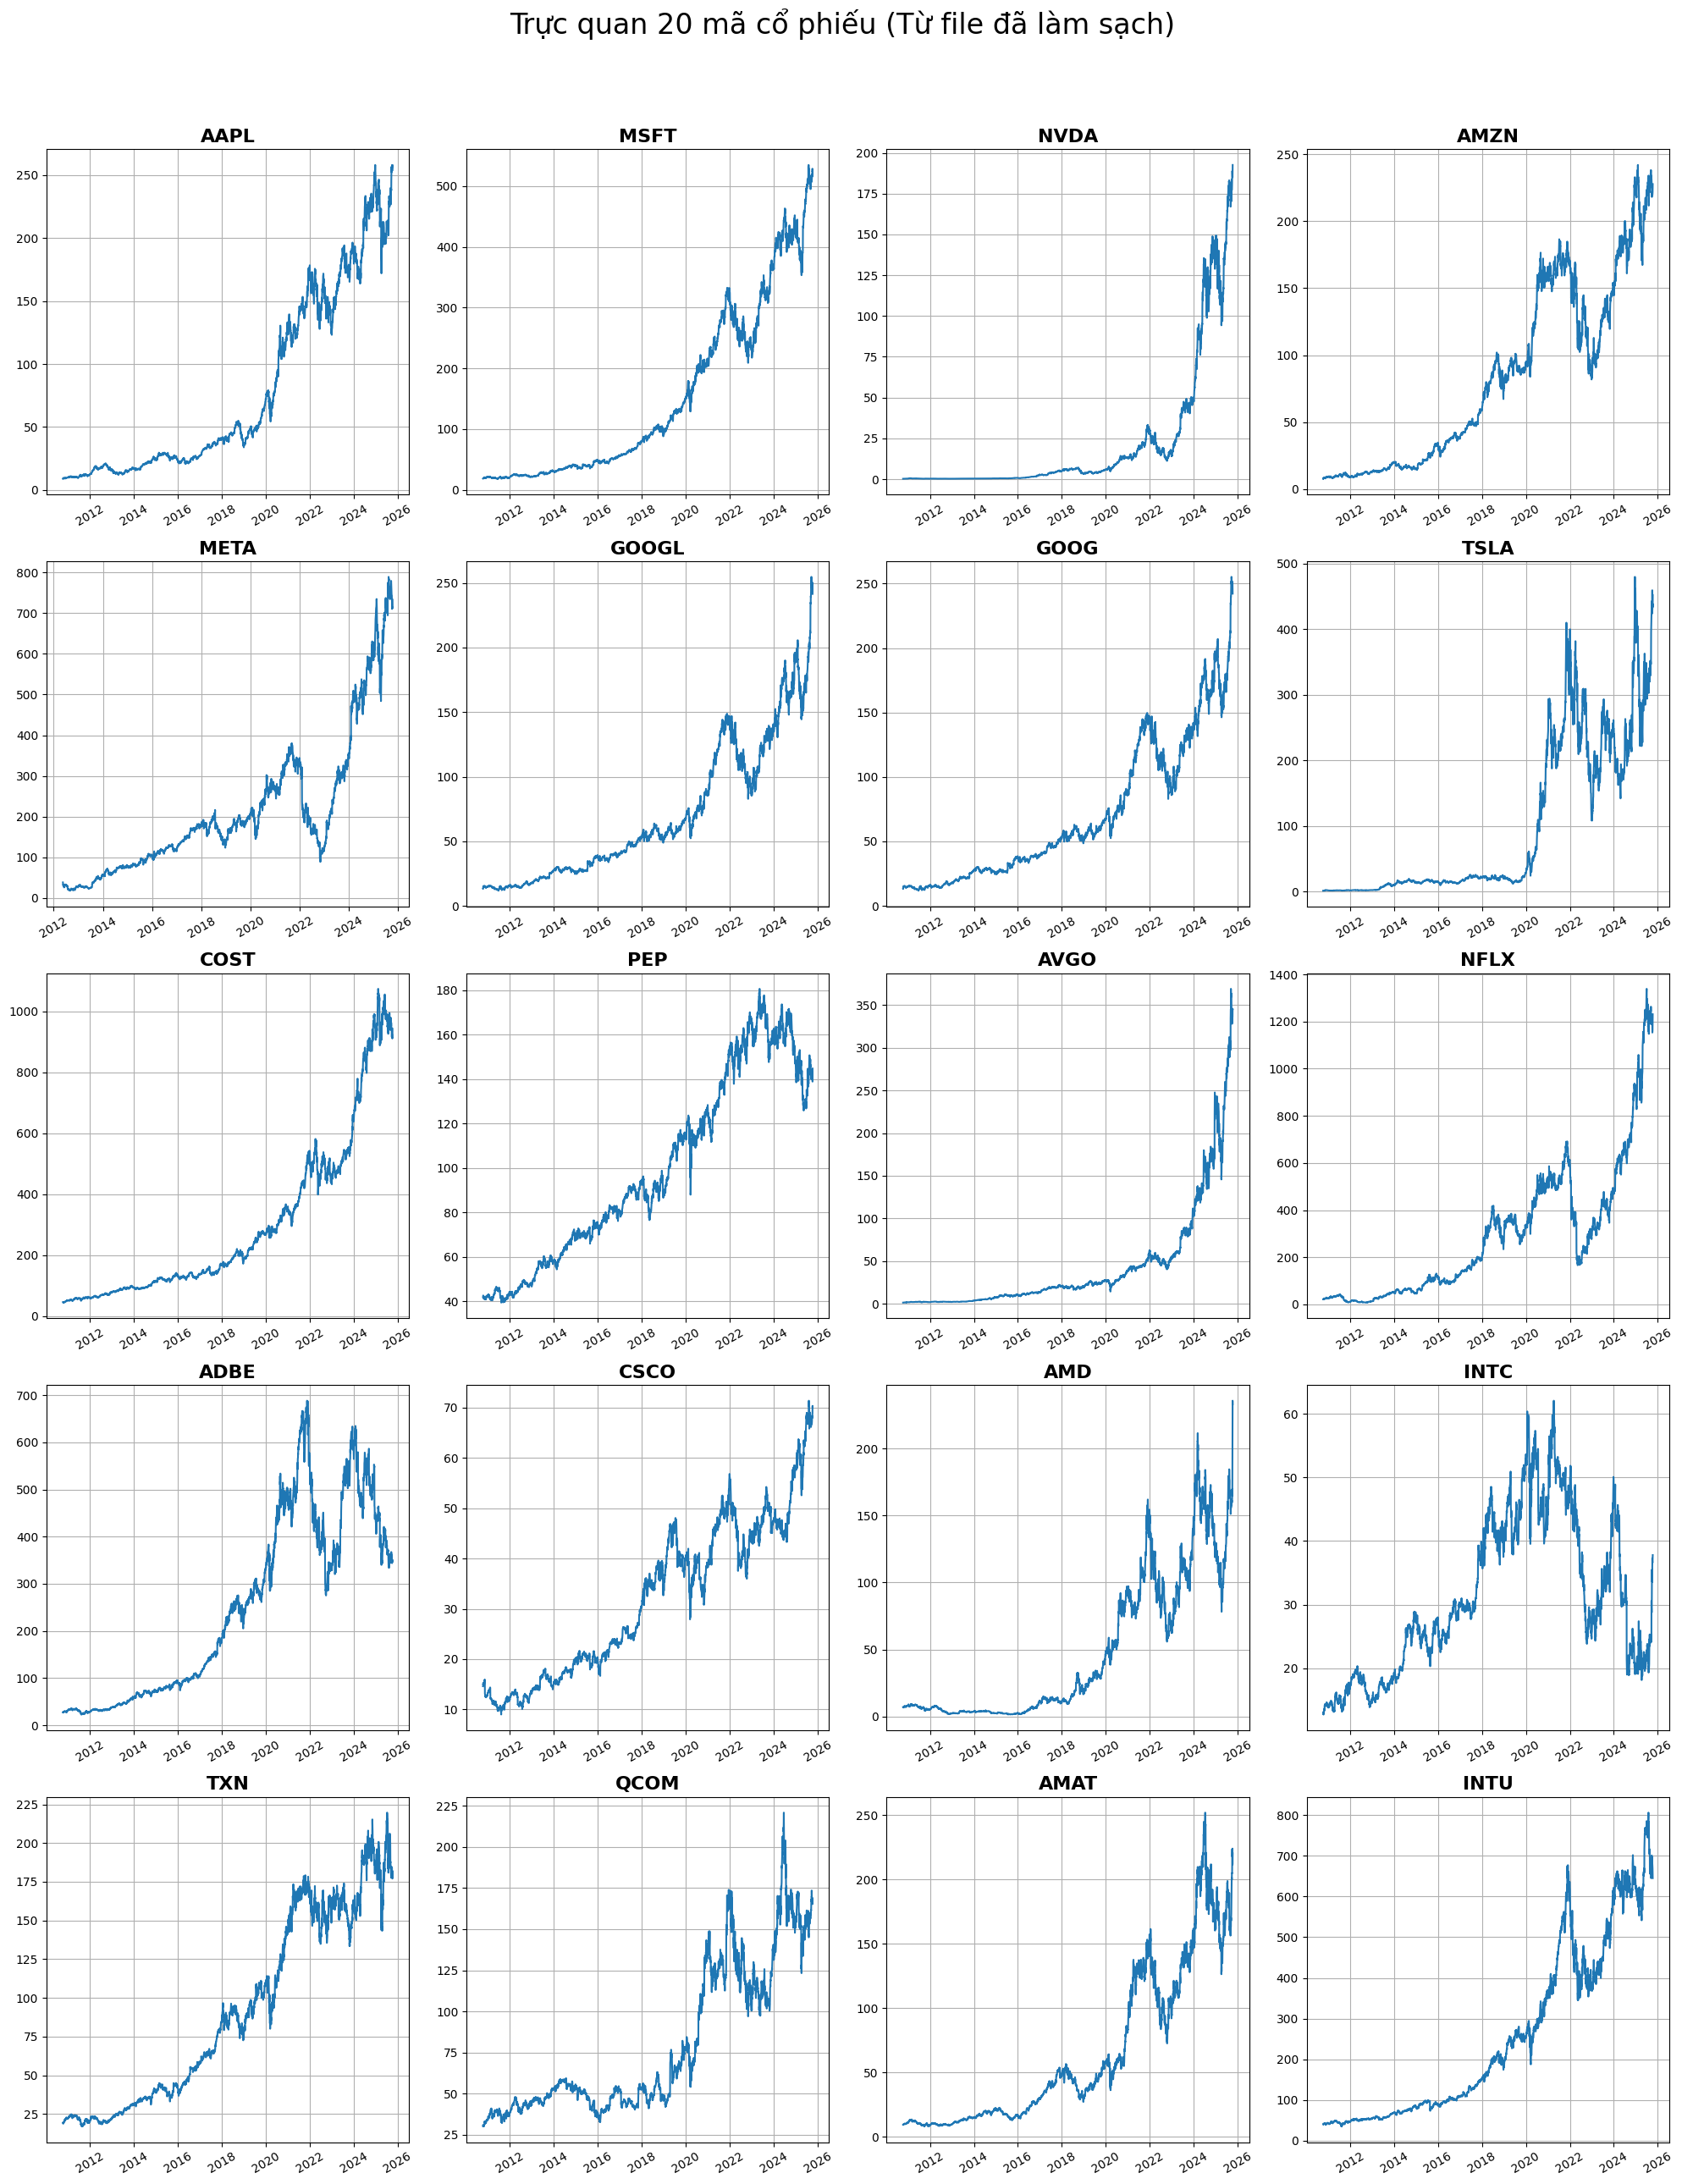

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

# Tắt các cảnh báo UserWarning không cần thiết
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. DANH SÁCH 20 MÃ ĐẦU TIÊN ---
first_20_tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "GOOG", "TSLA", "COST", "PEP",
    "AVGO", "NFLX", "ADBE", "CSCO", "AMD", "INTC", "TXN", "QCOM", "AMAT", "INTU"
]

# --- 2. ĐỊNH NGHĨA ĐƯỜNG DẪN ---
save_path = "/content/drive/MyDrive/StockData_15Years"

# --- 3. TẠO LƯỚI BIỂU ĐỒ ---
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 25))
fig.suptitle('Trực quan 20 mã cổ phiếu (Từ file đã làm sạch)', fontsize=24, y=1.03)

print(f"Bắt đầu vẽ 20 biểu đồ từ các file đã làm sạch...")
print("-" * 40)

# --- 4. VÒNG LẶP VÀ VẼ (TỪ FILE SẠCH) ---
for i, ticker in enumerate(first_20_tickers):

    row, col = i // 4, i % 4
    ax = axes[row, col]

    file_name = f"{ticker}.csv"
    full_file_path = os.path.join(save_path, file_name)

    try:
        # --- BƯỚC ĐỌC FILE ĐƠN GIẢN ---
        # Bây giờ file đã sạch, ta chỉ cần đọc bình thường
        # - index_col='Date': Lấy cột 'Date' làm chỉ mục
        # - parse_dates=True: Hiểu cột đó là ngày tháng

        df = pd.read_csv(
            full_file_path,
            index_col="Date",
            parse_dates=True
        )

        # --- BƯỚC VẼ BIỂU ĐỒ ---
        ax.plot(df['Adj Close']) # Lấy cột 'Adj Close'
        ax.set_title(ticker, fontsize=16, fontweight='bold')
        ax.tick_params(axis='x', rotation=30, labelsize=10)
        ax.grid(True)

    except FileNotFoundError:
        print(f"!!! LỖI: Không tìm thấy file {file_name}")
        ax.set_title(f"{ticker} (Không tìm thấy file)", color='red')
    except KeyError as e:
        # Lỗi này không nên xảy ra nữa, nhưng vẫn cẩn thận
        print(f"!!! LỖI: Không tìm thấy cột {e} trong file {file_name}")
        ax.set_title(f"{ticker} (Thiếu {e})", color='red')
    except Exception as e:
        print(f"!!! LỖI: {e} với mã {ticker}")
        ax.set_title(f"{ticker} (Lỗi)", color='red', fontsize=10)

print("-" * 40)

# --- 5. LƯU FILE ẢNH ---
plt.tight_layout()
chart_filename = "visualization_20_tickers_CLEAN.png"
chart_save_path = os.path.join(save_path, chart_filename)
plt.savefig(chart_save_path, dpi=150)

print("TẤT CẢ ĐÃ HOÀN TẤT!")
print(f"Đã lưu thành công ảnh tổng hợp 20 biểu đồ tại:")
print(chart_save_path)